<a href="https://colab.research.google.com/github/DMCBR/MVP_PUC-Rio_Manutencao_Preditiva/blob/main/MVP_Manutencao_Preditiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**MVP Análise de Dados e Boas Práticas - Manutenção Preditiva**

**Nome:** Daniel Massari de Souza Coelho

**Matrícula:** 4052025001403

**Dataset:** AI4I 2020 Predictive Maintenance Dataset

# Descrição do Problema

O conjunto de dados **AI4I 2020 Predictive Maintenance** reúne dados relacionados à operação de máquinas (equipamentos) industriais e à ocorrência de falhas. Entre as variáveis deste conjunto de dados, destacam-se as variáveis operacionais como temperatura do ar, temperatura do processo, velocidade de rotação, torque e desgaste da ferramenta, além de registros que indicam a ocorrência de falha da máquina e modos específicos de falha.

O objetivo deste trabalho é analisar esse conjunto de dados para compreender como as condições operacionais da máquina estão associadas à ocorrência de falhas. A partir dessa análise, busca-se desenvolver um modelo capaz de predizer se a máquina apresentará falha ou não, com base nas variáveis observadas durante sua operação. O trabalho analisará tanto a instância Machine Failure, que indica se há falha ou não, quanto dois modos de falhas específicos. O artigo *"Explainable Artificial Intelligence
for Predictive Maintenance Applications"* foi usado como base para entender o dataset.

Esse problema está relacionado à manutenção preditiva, que permite antecipar falhas, reduzir paradas não planejadas, diminuir custos de manutenção e aumentar a eficiência operacional.

##Hipóteses do Problema
As hipóteses levantadas para este trabalho são as seguintes:

- **Hipótese 1:** O conjunto de dados apresenta desbalanceamento entre as classes, com maior quantidade de observações sem falha do que com falha.

- **Hipótese 2:** Variáveis operacionais como torque, velocidade de rotação, temperatura do processo e desgaste da ferramenta influenciam a ocorrência de falhas.

- **Hipótese 3:** Certas combinações de variáveis operacionais podem estar mais associadas à falha do equipamento do que outras.

- **Hipótese 4:** É possível prever se um equipamento falhará a partir das variáveis operacionais disponíveis no dataset.

- **Hipótese 5:** Modelos especializados por modo de falha (HDF e OSF)  apresentam melhor desempenho preditivo do que um modelo generalista treinado sobre o target Machine failure, que agrega os resultados das falhas específicas.

##Seleção de Dados

O dataset **AI4I 2020 Predictive Maintenance** foi selecionado por ser uma base pública sobre manutenção preditiva. Além disso, trata-se de um conjunto de dados adequado para atividades de análise exploratória, pré-processamento, visualização gráfica e modelagem, pois reúne variáveis numéricas e categóricas relacionadas ao comportamento operacional de equipamentos industriais.

Outra vantagem desse dataset é sua estrutura organizada e bom número de registros e atributos, o que facilita a aplicação de técnicas estudadas nesta sprint.

##Atributos do Dataset

O dataset **AI4I 2020 Predictive Maintenance** contém 10.000 registros e 14 atributos:

- UDI: identificador único de cada registro.
- Product ID: identificador do produto.
- Type: tipo de produto, classificado em categorias de qualidade como L (baixa), M (média) e H (alta).
- Air temperature (K): temperatura do ar em Kelvin.
- Process temperature (K): temperatura do processo em Kelvin.
- Rotational speed (rpm): velocidade de rotação em rotações por minuto.
- Torque (Nm): torque em Newton-metro.
- Tool wear (min): desgaste da ferramenta em minutos.
- Machine failure: variável que indica se houve falha da máquina.
- TWF: falha por desgaste da ferramenta.
- HDF: falha por dissipação de calor.
- PWF: falha por energia.
- OSF: falha por sobre-esforço.
- RNF: falha aleatória.

# **Importação das Bibliotecas Necessárias e Carga de Dados**
Importação das bibliotecas utilizadas em todo o MVP, carregamento do dataset **AI4I 2020 Predictive Maintenance** direto do repositório UCI Machine Learning Repository e criação dos datasets que serão analisados e trabalhados para responder às hipóteses deste MVP.

Foram criados os datasets:
- **ds_machine** — target: Machine failure (falha geral da máquina)
- **ds_hdf** — target: HDF (falha por dissipação de calor)
- **ds_osf** — target: OSF (falha por sobre-esforço)

In [1]:
!pip install ucimlrepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from typing import List, Tuple
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

In [2]:
# Tupla (não precisa ser alterada) com targets e IDs.
ALL_FAILURE_MODES: Tuple[str, ...] = ('TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine failure')
ID_COLUMNS: Tuple[str, ...] = ('UDI', 'Product ID')

class TargetValidator:
    """
    Valida se o nome do target está na tupla.
    """
    def validate(target: str, valid_modes: Tuple[str, ...]) -> None:
        if target not in valid_modes:
            raise ValueError(
                f"Target '{target}' inválido. "
                f"Escolha entre os targets da lista: {list(valid_modes)}"
            )

class DataLoader:
    """
    Carrega o dataset da UCI.
    """
    def load_from_ucirepo(dataset_id: int = 601) -> pd.DataFrame:
        maintenance = fetch_ucirepo(id=dataset_id)
        df = pd.concat(
            [maintenance.data.features, maintenance.data.targets],
            axis=1
        )
        df.columns = df.columns.str.strip()
        return df

class ColumnDropper:
    """
    Drop das colunas (target) que não serão usadas.
    """
    def drop(
        df: pd.DataFrame,
        columns: List[str]
    ) -> pd.DataFrame:
        return df.drop(columns=columns, errors='ignore')

class PredictiveMaintenanceDS:
    """
    Principal classe que recebe os dados sem as colunas que não serão necessárias.
    """
    def __init__(
        self,
        df: pd.DataFrame,
        target: str,
        valid_modes: Tuple[str, ...] = ALL_FAILURE_MODES,
        id_columns: Tuple[str, ...] = ID_COLUMNS
    ) -> None:
        TargetValidator.validate(target, valid_modes)

        self.target = target
        self.valid_modes = valid_modes

        cols_to_drop = (
            [col for col in valid_modes if col != target]
            + list(id_columns)
        )

        self.data = ColumnDropper.drop(df, cols_to_drop)
        self.X = self.data.drop(columns=[target])
        self.y = self.data[target]

    def check(self) -> None:
        """
        Confere os dados de cada dataframe.
        """
        print("\n" + "=" * 125 + "\n")
        print(f"Target: {self.target}")
        print(f"Shape: {self.data.shape}")
        print(f"Atributos: {list(self.data.columns)}")
        print("\nDistribuição:")
        print(self.y.value_counts())
        print("\nProporção:")
        print(self.y.value_counts(normalize=True))
        print("=" * 125)

In [3]:
# Criação dos datasets
df_raw = DataLoader.load_from_ucirepo()

ds_machine = PredictiveMaintenanceDS(df_raw, target='Machine failure')
ds_hdf     = PredictiveMaintenanceDS(df_raw, target='HDF')
ds_osf     = PredictiveMaintenanceDS(df_raw, target='OSF')

ds_machine.check()
ds_hdf.check()
ds_osf.check()



Target: Machine failure
Shape: (10000, 7)
Atributos: ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure']

Distribuição:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Proporção:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


Target: HDF
Shape: (10000, 7)
Atributos: ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'HDF']

Distribuição:
HDF
0    9885
1     115
Name: count, dtype: int64

Proporção:
HDF
0    0.9885
1    0.0115
Name: proportion, dtype: float64


Target: OSF
Shape: (10000, 7)
Atributos: ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'OSF']

Distribuição:
OSF
0    9902
1      98
Name: count, dtype: int64

Proporção:
OSF
0    0.9902
1    0.0098
Name: proportion, dtype: float64


In [4]:
# Vizualização das primeiras linhas
ds_machine.data.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [5]:
# Vizualização das primeiras linhas
ds_hdf.data.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,HDF
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


# **Análise de Dados**
Análise exploratória dos dados para compreender a estrutura do dataset,
identificar padrões relevantes e embasar as decisões de pré-processamento.
Esta etapa também contribui diretamente para responder às Hipóteses 1, 2 e 3.

Foram analisados estatísticas descritivas (importantes para as features),
distribuições das variáveis (histogramas), relações entre variáveis e
classes (boxplots e scatter plots) e correlações entre features
(matriz de correlação).

In [6]:
class ExploratoryAnalysis:
    """
    Realiza análise exploratória de dados de manutenção preditiva.
    """
    def __init__(self, dataset: PredictiveMaintenanceDS) -> None:
        """
        Inicializa com dataset e identifica colunas numéricas.
        """
        self.ds = dataset
        self.numerical_cols = dataset.X.select_dtypes(
            include=np.number
        ).columns.tolist()

    def summary(self) -> None:
        """
        Exibe informações gerais e estatísticas descritivas.
        """
        print(f"Total de instâncias: {len(self.ds.data)}")
        print(f"\nTipos de dados:")
        print(self.ds.data.dtypes)
        print(f"\nEstatísticas descritivas:\n\n")
        display(self.ds.data.describe())

    def class_distribution(self) -> None:
        """
        Gráfico de distribuição das classes.
        """
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.countplot(x=self.ds.y, hue=self.ds.y, palette='viridis',
                      legend=False, ax=ax)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Operação Normal', 'Falha'])
        ax.set_title(f'Distribuição — {self.ds.target}')
        ax.set_xlabel('Estado da Máquina')
        ax.set_ylabel('Número de Registros')
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=12)
        plt.show()

    def histograms(self) -> None:
        """
        Histogramas de distribuição das variáveis numéricas.
        """
        for col in self.numerical_cols:
            fig, ax = plt.subplots(figsize=(8, 6))
            sns.histplot(self.ds.data[col], kde=True, ax=ax)
            ax.set_title(f'Distribuição — {col}')
            ax.set_xlabel(col)
            ax.set_ylabel('Frequência')
            plt.show()

    def mean_by_class(self) -> None:
        """
        Média das variáveis por classe. Hipótese 1.
        """
        print(f"\nMédia por classe — {self.ds.target}:\n")
        display(
            self.ds.data.groupby(self.ds.target)[self.numerical_cols].mean()
        )

    def boxplots(self) -> None:
        """
        Boxplots das variáveis numéricas segmentados por classe.
        """
        n = len(self.numerical_cols)
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        axes = axes.flatten()

        for i, col in enumerate(self.numerical_cols):
            sns.boxplot(x=self.ds.y, y=self.ds.data[col],
                        hue=self.ds.y, palette='viridis', ax=axes[i])
            axes[i].set_title(f'{col} vs {self.ds.target}')
            axes[i].set_xlabel('Falha (0 = Não, 1 = Sim)')
            axes[i].set_ylabel(col)

        # Não mostra os gráficos vazios.
        for j in range(n, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

    def scatter_pairs(self) -> None:
        """
        Scatter plots dos pares de variáveis mais relevantes. Hipótese 2.
        """
        pairs = [
            ('Torque', 'Rotational speed'),
            ('Torque', 'Tool wear'),
            ('Air temperature', 'Process temperature')
        ]
        for x, y in pairs:
            fig, ax = plt.subplots(figsize=(8, 6))
            sns.scatterplot(x=self.ds.data[x], y=self.ds.data[y],
                            hue=self.ds.y, palette='viridis',
                            alpha=0.5, ax=ax)
            ax.set_title(f'{x} vs {y} — {self.ds.target}')
            ax.set_xlabel(x)
            ax.set_ylabel(y)
            plt.show()

    def failure_by_type(self) -> None:
        """
        Taxa de falha por tipo de produto.
        """
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.countplot(x=self.ds.data['Type'], hue=self.ds.y,
                      palette='viridis', ax=ax)
        ax.set_title(f'Falhas por Tipo de Produto — {self.ds.target}')
        ax.set_xlabel('Tipo')
        ax.set_ylabel('Contagem')
        plt.show()

    def temperature_delta(self) -> None:
        """
        Diferença entre temperaturas do processo e do ar, específica para HDF.
        8.6k está descrito no artigo de Matzka, S (2020).
        """
        if self.ds.target != 'HDF':
            print(
                f"Análise de delta de temperatura é específica para HDF. "
                f"Target atual: '{self.ds.target}'. Análise ignorada."
            )
            return
        delta = (self.ds.data['Process temperature']
                 - self.ds.data['Air temperature'])
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.boxplot(x=self.ds.y, y=delta, hue=self.ds.y,
                    palette='viridis', ax=ax)
        ax.set_title(f'Diferença de Temperatura vs {self.ds.target}')
        ax.set_xlabel('Falha (0 = Não, 1 = Sim)')
        ax.set_ylabel('Process Temp - Air Temp (K)')
        plt.axhline(y=8.6, color='red', linestyle='--',
                    label='Limiar HDF (8.6K)')
        ax.legend()
        plt.show()

    def correlation_heatmap(self) -> None:
        """
        Mapa de calor da matriz de correlação entre variáveis numéricas.
        """
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(self.ds.data[self.numerical_cols].corr(),
                    annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
        ax.set_title(f'Matriz de Correlação — {self.ds.target}')
        plt.show()

    def outliers(self) -> pd.DataFrame:
        """
        Detecta e retorna outliers pelo método IQR.
        """
        results = []
        for col in self.numerical_cols:
            q1 = self.ds.data[col].quantile(0.25)
            q3 = self.ds.data[col].quantile(0.75)
            iqr = q3 - q1
            n = ((self.ds.data[col] < q1 - 1.5 * iqr) |
                 (self.ds.data[col] > q3 + 1.5 * iqr)).sum()
            results.append({
                'variavel': col,
                'outliers': n,
                'percentual': round(n / len(self.ds.data) * 100, 2)
            })
        return pd.DataFrame(results)

    def run_features(self) -> None:
        """
        Executa análises independentes do target. Features operacionais.
        """
        self.summary()
        self.histograms()
        self.scatter_pairs()
        self.correlation_heatmap()
        display(self.outliers())

    def run_target(self) -> None:
        """
        Executa análises que dependem do target selecionado.
        """
        self.class_distribution()
        self.mean_by_class()
        self.boxplots()
        self.failure_by_type()
        self.temperature_delta()

    def run_all(self) -> None:
        """
        Executa toda a EDA em sequência.
        """
        self.run_features()
        self.run_target()


## Análise das Features Operacionais
As features são iguais para todos os dataframes e, por isso, foram analisados somente uma vez. O dataset ds_machine foi escolhido.

Total de instâncias: 10000

Tipos de dados:
Type                    object
Air temperature        float64
Process temperature    float64
Rotational speed         int64
Torque                 float64
Tool wear                int64
Machine failure          int64
dtype: object

Estatísticas descritivas:




,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


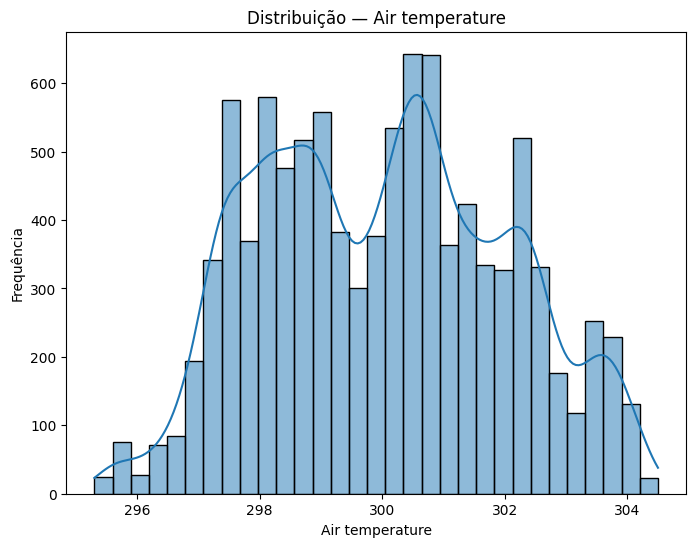

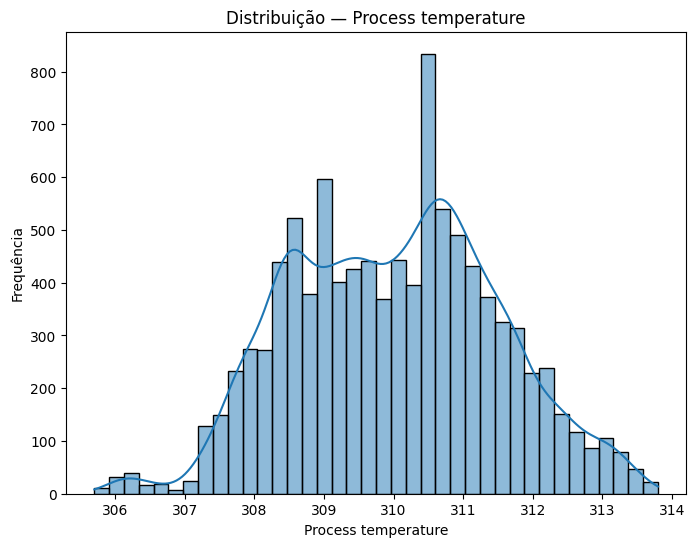

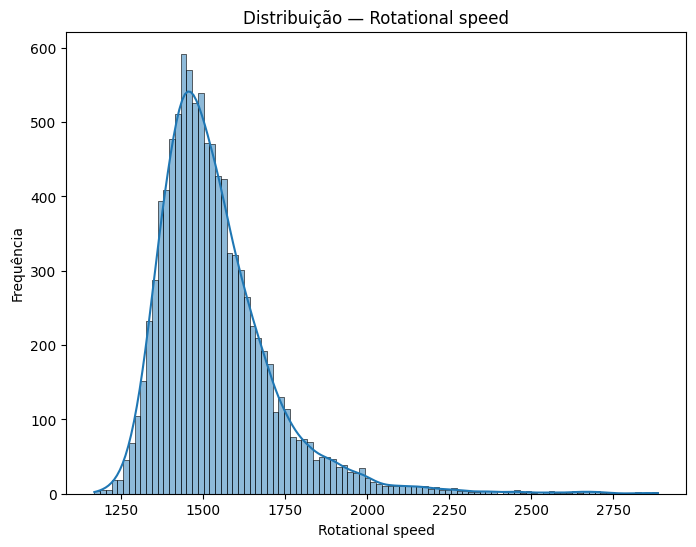

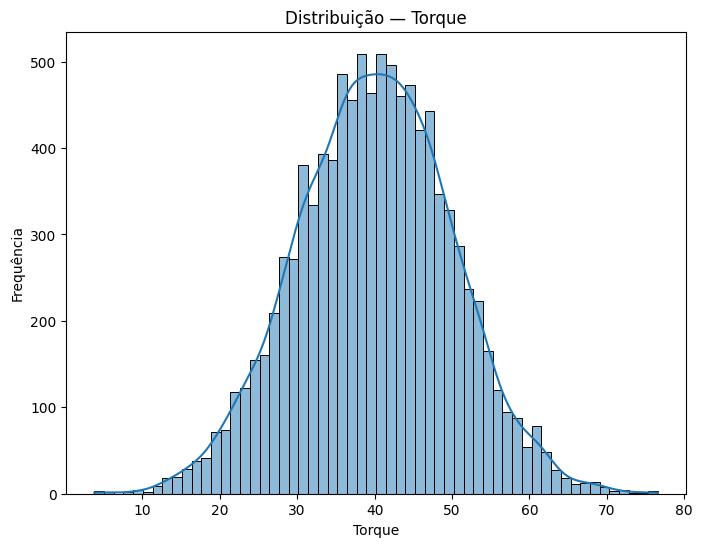

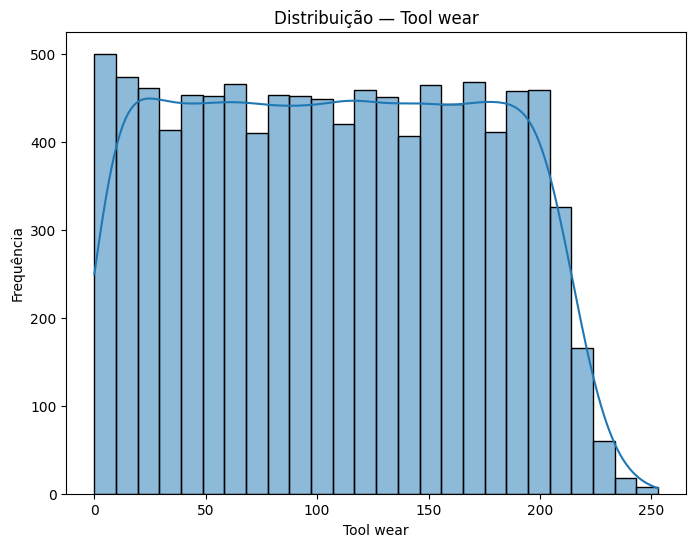

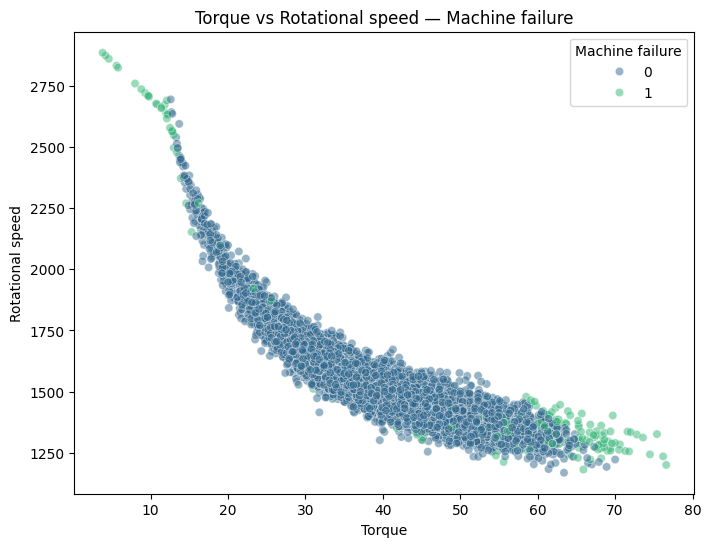

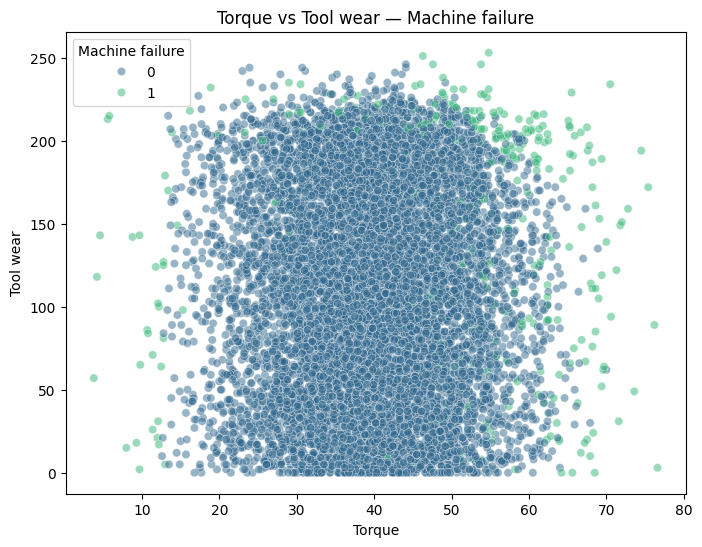

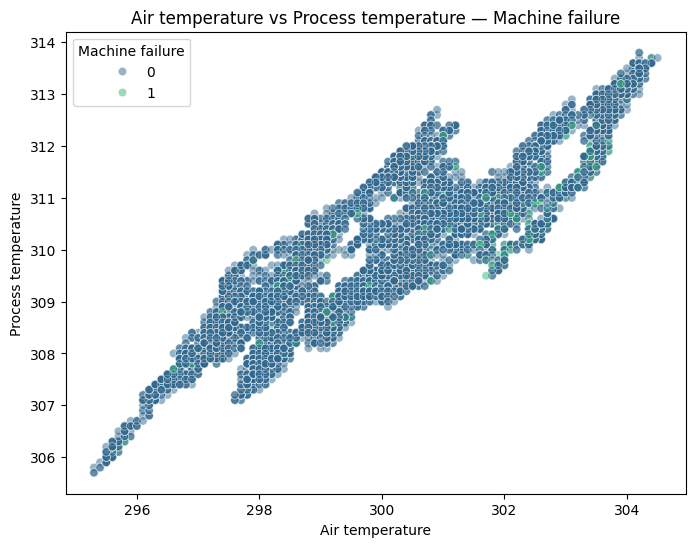

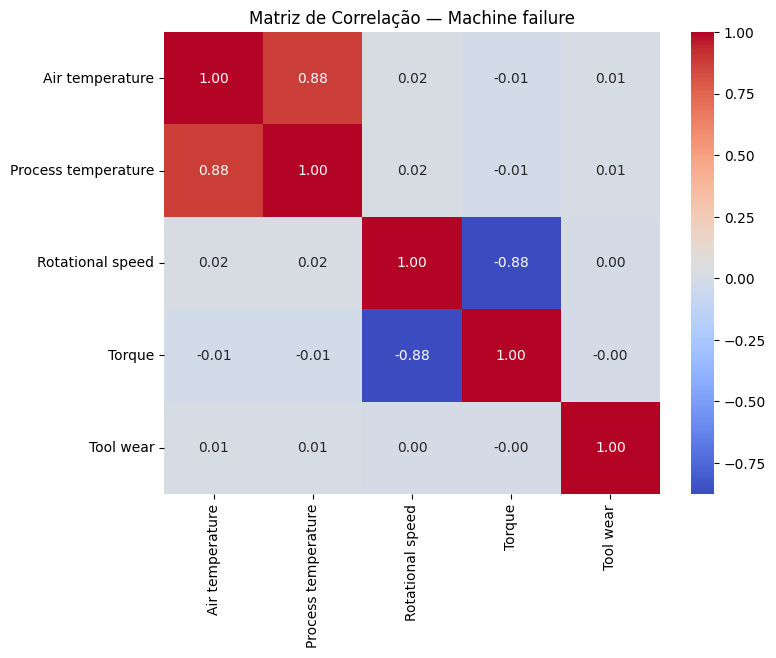

,variavel,outliers,percentual
0,Air temperature,0,0.00
1,Process temperature,0,0.00
2,Rotational speed,418,4.18
3,Torque,69,0.69
4,Tool wear,0,0.00


In [7]:
# Análises das features. Iguais para todos os targets.
eda_machine = ExploratoryAnalysis(ds_machine)
eda_machine.run_features()

###Análise dos gráficos - Informações mais relevantes
**Histogramas**
- Air temperature (temperatura do ar): distribuição bimodal com picos em torno de 298 e 301K.
- Process temperature (temperatura de processo): distribuição normal.
- Rotational speed (velocidade de rotação): distribuição assimétrica à direita. Pode indicar outliers.
- Torque: distribuição normal. Gráfico mais próximo ao normal de todos os histogramas.
- Tool wear (desgaste da ferramenta): distribuição uniforme.

**Scatter pairs**
- Torque vs rotational speed (velocidade de rotação): Hiperbólica decrescente. Quando o torque é baixo, a rotação é alta. Quando o toque é alto, a rotação é baixa. As falhas se concentram nas extremidades. Isso confirma que há uma relação entre torque e velocidade de rotação relacionado à falha.
- Torque vs tool wear (desgaste de ferramenta): não há como confirmar a relação entre as duas variáveis e a relação com falha na região central onde há um sobreposicionamento. Há mais falhas nas extremidades.
- Air temperature (temperatura do ar) vs Process temperature (temperatura do processo): correlação linear crescente é alta. A temperatura de processo é  aproximadamente 10K maior que a do ar em todos os pontos.  Os casos de falha estão misturados com os de operação normal,  sem separação visual, indicando pouca relação direta com falha.

**Matriz de correlação**
- Air temperature e process temperature:  correlação positiva alta (0,88) muito forte.
- Torque e rotational speed:  correlação negativa alta (-0,88).
- Tool wear e todas as outras: correlação fraca. O desgaste da ferramenta não tem relação linear com nenhuma outra variável operacional.

##Machine Failure - Falhas Gerais
Análise do dataset ds_machine para compreender a relação do target Machine Failure com as features operacionais.


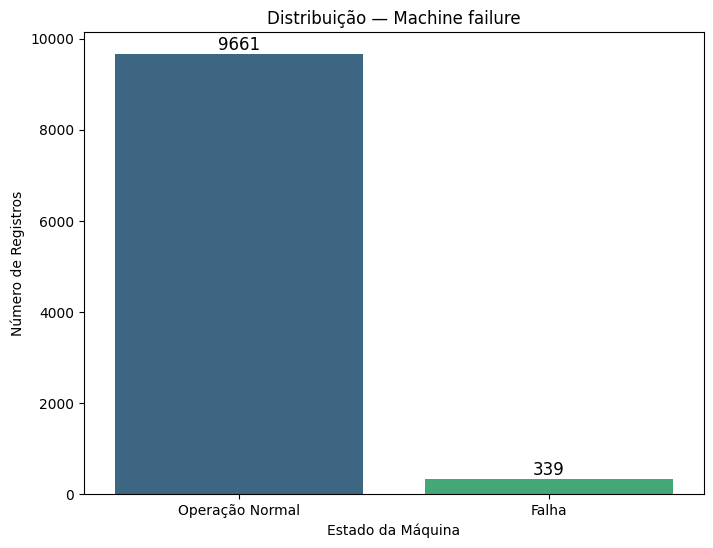


Média por classe — Machine failure:



,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


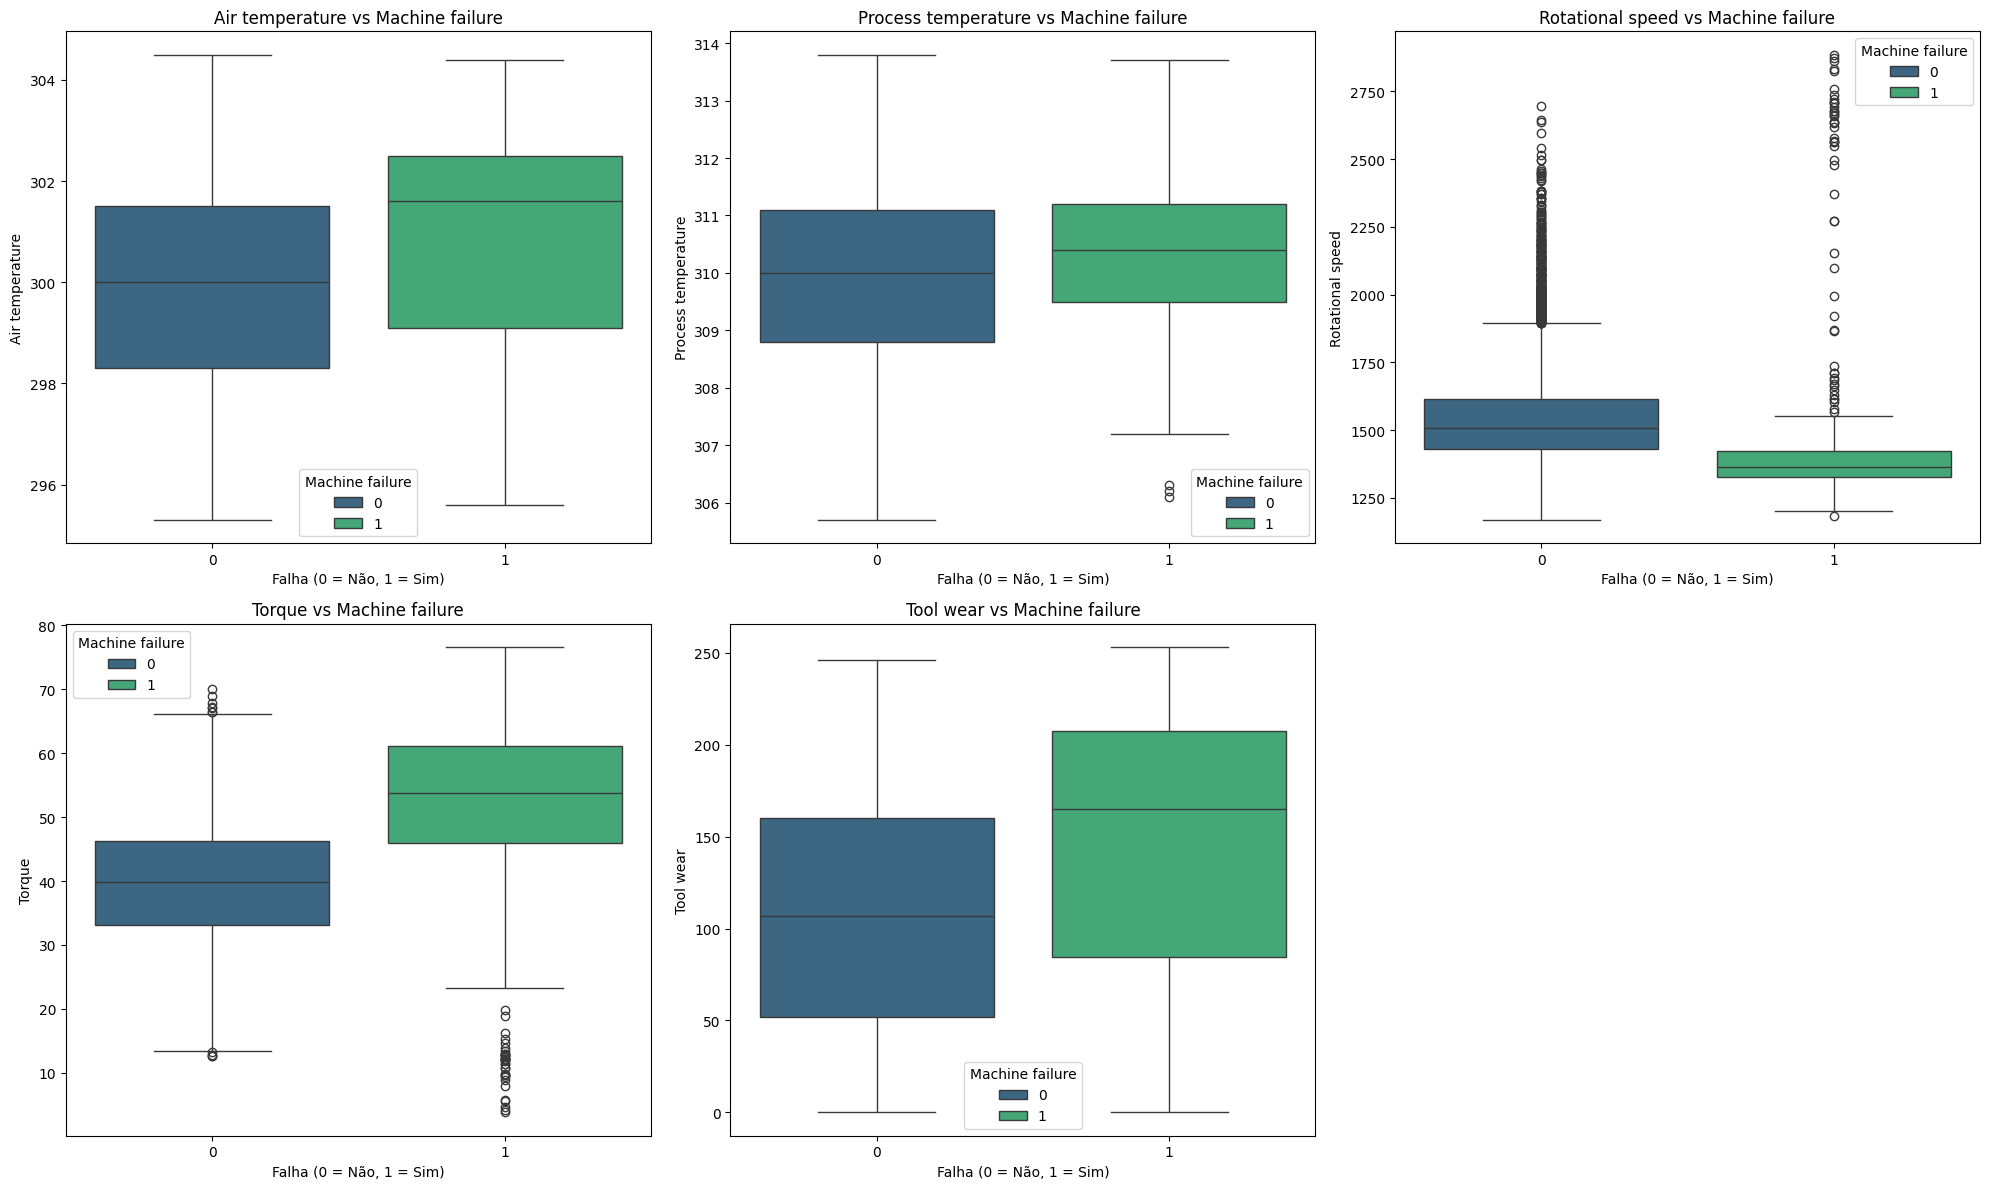

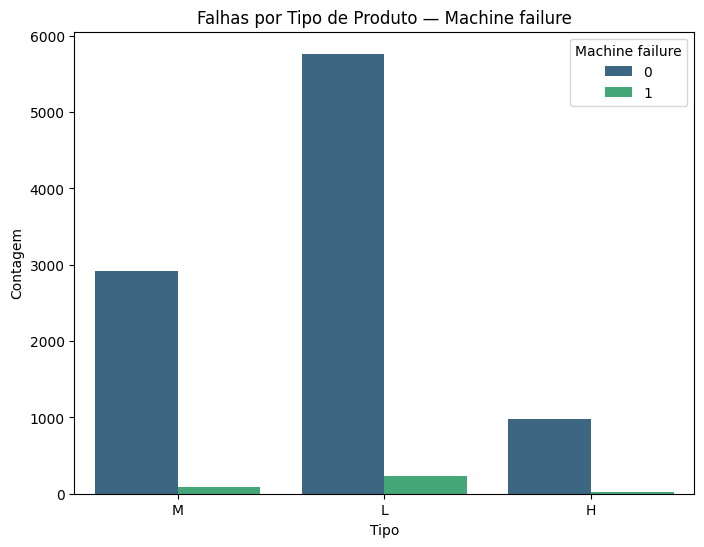

Análise de delta de temperatura é específica para HDF. Target atual: 'Machine failure'. Análise ignorada.


In [8]:
# Análise somente do target Machine Failure
eda_machine.run_target()




**Distribuição de classes**
- Alto desbalanceamento: 9.661 operações normais contra 339 falhas (3,4%).

**Média por classe**
- Maiores diferenças no torque e desgaste da ferramenta.

**Boxplot**
- Air Temperature: falhas em temperaturas mais altas.
- Rotational speed: falhas em rotação mais baixa.
- Torque: falhas operam com torque mais alto.
- Tool wear: falhas ocorrem com maior desgaste acumulado.

**Falhas por tipo de produto**
- O tipo L concentra mais número de falhas.

##HDF - Falha por Dissipação de Calor
Análise do dataset ds_hdf para compreender a relação do target HDF com as features operacionais.
Para este target foi analisada também  a diferença entre a temperatura do processo e a temperatura do ar,  por ser o principal indicador deste modo de falha conforme descrito  em Matzka (2020)

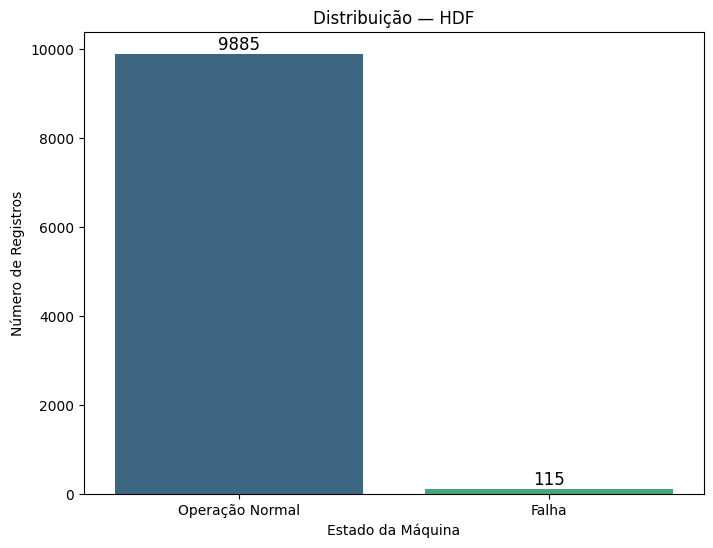


Média por classe — HDF:



,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
HDF,,,,,
0,299.975195,309.996449,1541.120486,39.833576,107.959838
1,302.560870,310.788696,1337.260870,53.166957,107.191304


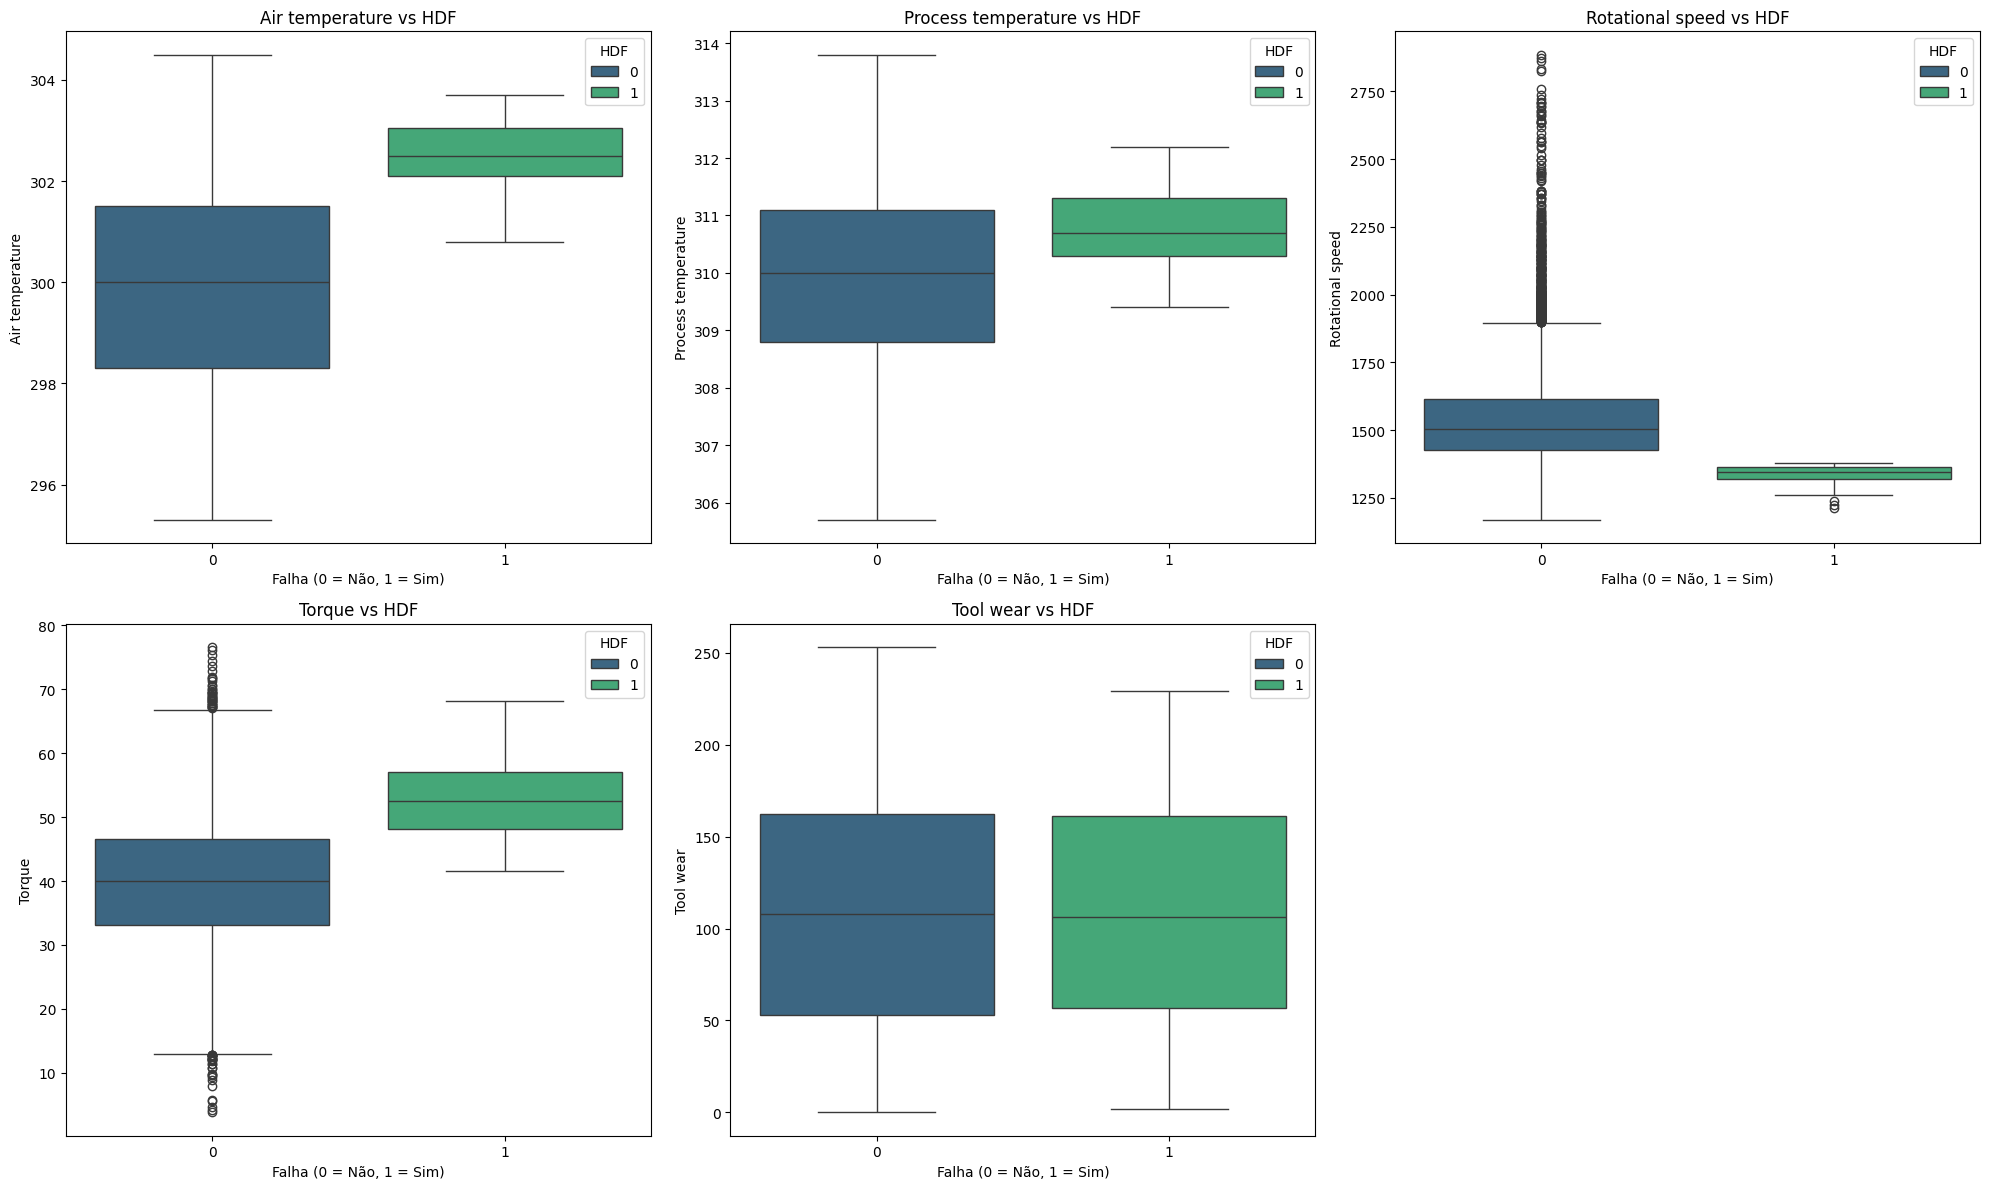

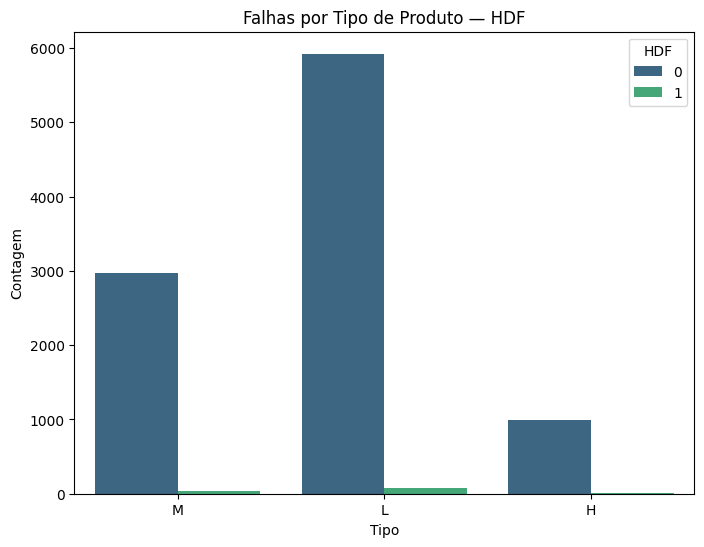

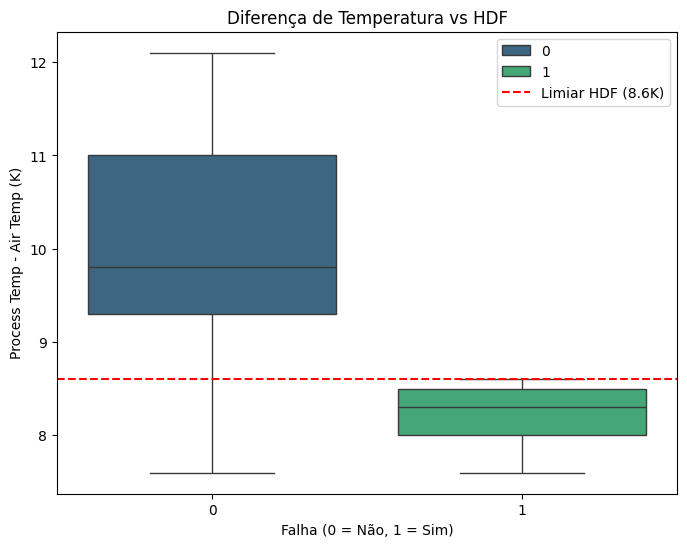

In [9]:
# Análise somente do target HDF
eda_hdf = ExploratoryAnalysis(ds_hdf)
eda_hdf.run_target()

###Análise dos Gráficos - Informações Mais Relevantes

**Média por classe**
- Air temperature: falhas ocorrem com temperatura do ar mais alta. Cerca de 2K.
- Rotational speed: falhas ocorrem com rotação mais baixa.
- Torque: falhas ocorrem com torque mais alto.
- Tool wear: Não há diferenciação entre falha e operação normal.

**Boxplot**
- Air temperature: falha em temperaturas mais altas que a de operação normal.
- Rotational speed: torque também mostra separação relevante com falha em rotações mais baixas.
- Diferença de temperatura: separação em relação ao limite de 8,6K. Há uma separação relevante entre as duas caixas.

**Falhas por tipo**
- Número de falhas semelhantes para cada tipo.






##OSF - Falha por Sobre-Esforço
Análise do dataset ds_osf para compreender a relação do target OSF
com as features operacionais.

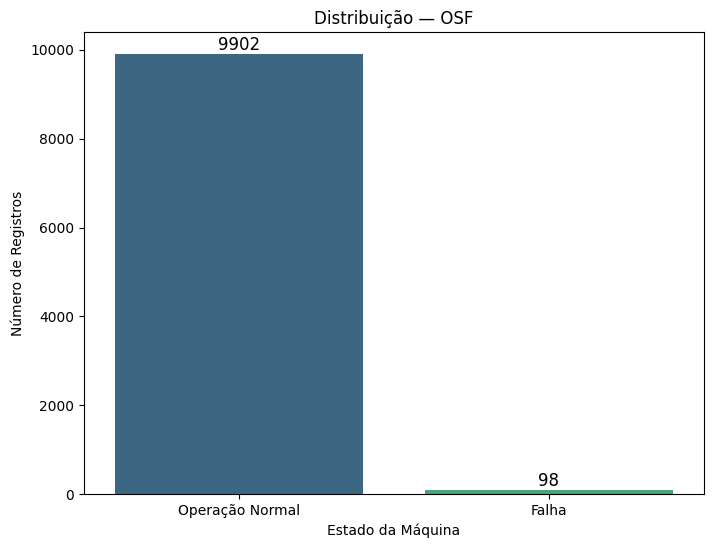


Média por classe — OSF:



,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
OSF,,,,,
0,300.004534,310.004888,1540.641184,39.804969,106.963846
1,300.044898,310.073469,1350.326531,58.370408,207.693878


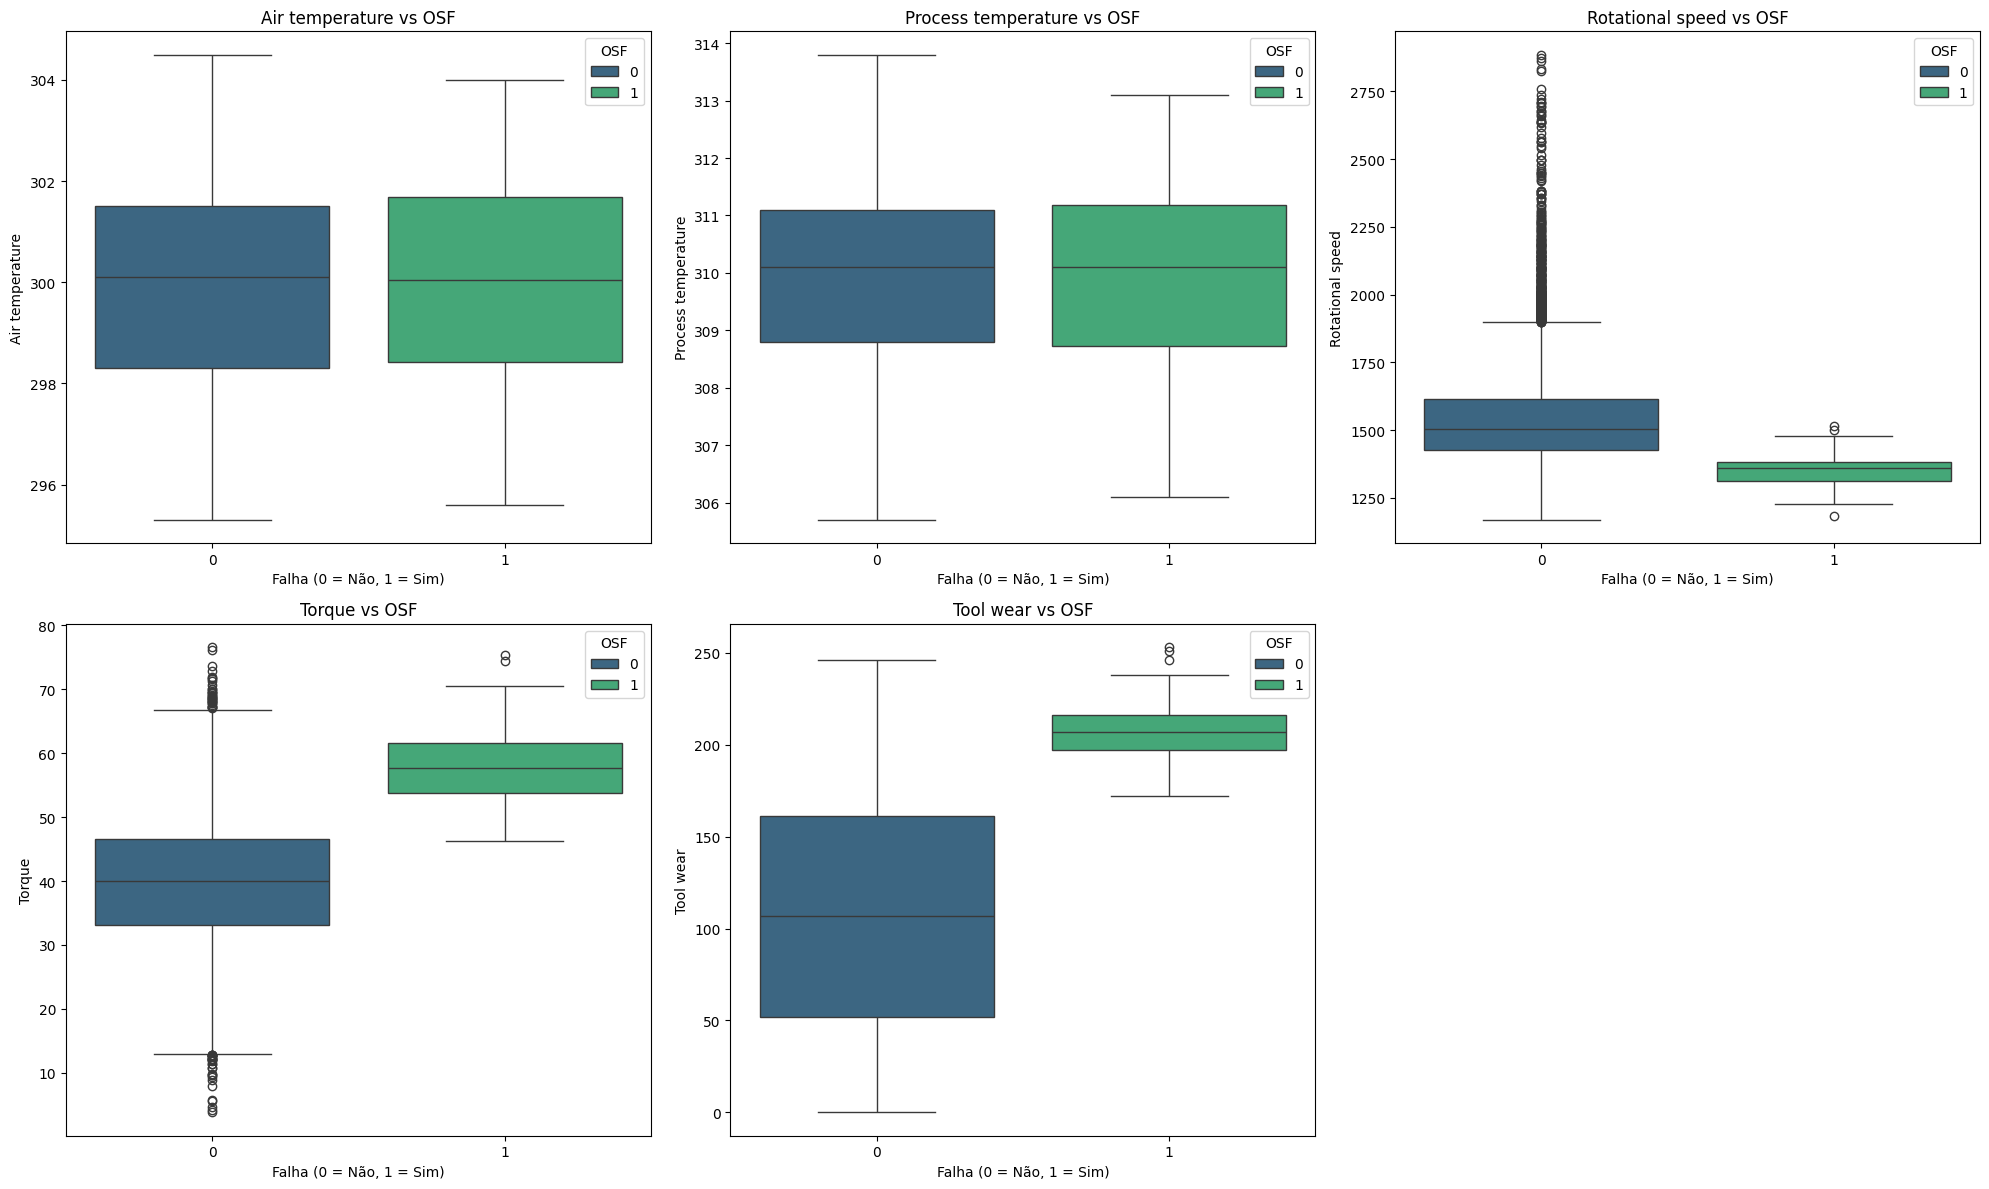

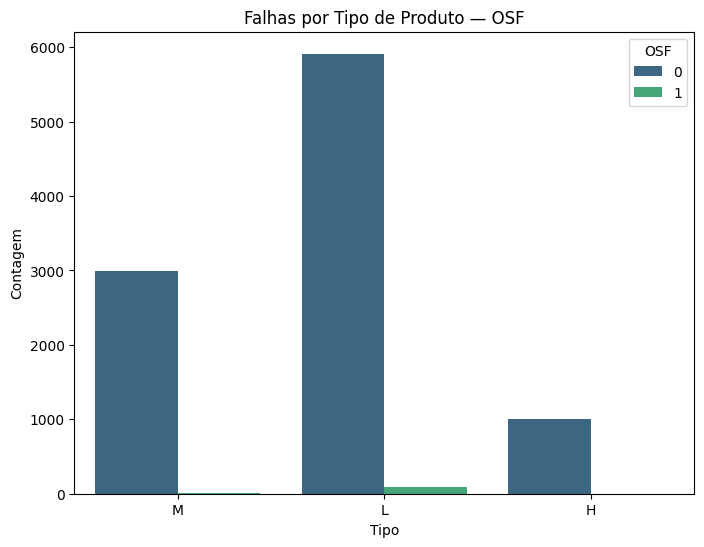

Análise de delta de temperatura é específica para HDF. Target atual: 'OSF'. Análise ignorada.


In [10]:
# Análise - Target OSF
eda_osf = ExploratoryAnalysis(ds_osf)

eda_osf.run_target()

###Análise dos Gráficos - Informações Mais Relevantes
**Média por classe**

- Torque: diferença entre operação normal e falha é de quase 20 Nm, indicando que é relevante para a falha.
- Tool wear: diferença de 100 minutos entre operação normal e falha, indicando que é relevante para a falha.
Rotational speed: diferença relevante, mas menor que os intens anteriores.

**Boxplot**

- Torque: há uma separação entre operação normal e falha.
- Tool wear: há uma separação entre operação normal e falha. Falhas ocorrem  na sua maioria acima de 190 minutos e a operação normal ocorre entre 0 e 160 minutos.
- Rotational speed: separação presente, mas com muita sobreposição entre operação normal e falha.

**Falhas por tipo**

Falhas concentradas no tipo L.

#Pré-Processamento de Dados
Divisão entre treinamento e teste, padronização e balanceamento dos dados para os três targets analisados.

A padronização (StandardScaler) foi escolhida em vez da normalização (MinMaxScaler) por dois motivos: o Random Forest é robusto para outliers e a padronização preserva melhor a informação dos valores extremos.

O pré-processamento segue a seguinte sequência:

- **Feature Engineering** — criação da feature "Temperature delta" para HDF.
- **Split** — divisão 70/30 com estratificação por classe para treinamento e teste.
- **Padronização** — StandardScaler nas variáveis numéricas e OneHotEncoder na variável categórica Type.
- **Balanceamento** — SMOTE aplicado apenas no conjunto de treino.

In [11]:
# Adição do delta de temperatura
class FeatureEngineer:
    """
    Cria novas features a partir das existentes.
    """

    @staticmethod
    def add_temperature_delta(dataset: PredictiveMaintenanceDS) -> PredictiveMaintenanceDS:
        """
        Adiciona delta entre temperatura do processo e do temperatura do ar.
        Relevante para HDF
        """
        dataset.data = dataset.data.copy()
        dataset.data['Temperature delta'] = (
            dataset.data['Process temperature']
            - dataset.data['Air temperature']
        )
        dataset.X = dataset.data.drop(columns=[dataset.target])
        return dataset

In [12]:
class Preprocessor:
    """
    Realiza split, padronização e balanceamento dos dados.
    """

    def __init__(self, dataset: PredictiveMaintenanceDS, test_size: float = 0.3,
                 random_state: int = 42) -> None:
        """
        Inicializa o dataset e parâmetros de split.
        """
        self.ds = dataset
        self.test_size = test_size
        self.random_state = random_state
        self.preprocessor = None

        self._split()
        self._preprocess()
        self._balance()

    def _split(self) -> None:
        """
        Divide os dados em treino e teste.
        """
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.ds.X, self.ds.y,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=self.ds.y
        )

    def _preprocess(self) -> None:
        """
        Padronização. Aplica StandardScaler nas numéricas e OneHotEncoder na categórica.
        """
        numerical = self.X_train.select_dtypes(include=np.number).columns
        categorical = self.X_train.select_dtypes(include='object').columns

        self.preprocessor = ColumnTransformer(transformers=[
            ('num', StandardScaler(), numerical),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
        ])

        self.X_train_processed = self.preprocessor.fit_transform(self.X_train)
        self.X_test_processed = self.preprocessor.transform(self.X_test)

    def _balance(self) -> None:
        """
        Balanceamento. Aplica SMOTE para balanceamento da classe minoritária.
        """
        smote = SMOTE(random_state=self.random_state)
        self.X_train_bal, self.y_train_bal = smote.fit_resample(
            self.X_train_processed, self.y_train
        )

    def check(self) -> None:
        """
        Exibe dimensões e distribuição antes e depois do SMOTE.
        """
        print(f"X_train: {self.X_train.shape} | X_test: {self.X_test.shape}")
        print(f"\nANTES do SMOTE: {self.y_train.value_counts().to_dict()}")
        print(f"DEPOIS do SMOTE: {self.y_train_bal.value_counts().to_dict()}")

    def check_preprocessing(self) -> None:
        """
        Verifica se o pré-processamento foi aplicado corretamente.
        """
        print("\n" + "=" * 50)
        print(f" TARGET: {self.ds.target}")
        print("=" * 50)

        # Verifica dimensões
        print("=== Dimensões ===")
        print(f"X_train:           {self.X_train.shape}")
        print(f"X_test:            {self.X_test.shape}")
        print(f"X_train_processed: {self.X_train_processed.shape}")
        print(f"X_test_processed:  {self.X_test_processed.shape}")
        print(f"X_train_bal:       {self.X_train_bal.shape}")

        # Verifica balanceamento
        print("\n=== Balanceamento ===")
        print(f"ANTES do SMOTE: {self.y_train.value_counts().to_dict()}")
        print(f"DEPOIS do SMOTE: {self.y_train_bal.value_counts().to_dict()}")

        # Verifica média e desvio padrão das numéricas após padronização
        print("\n=== Padronização (deve ser média \u2248 0, std \u2248 1) ===")
        n_numerical = self.X_train.select_dtypes(include=np.number).shape[1]
        processed_numerical = self.X_train_processed[:, :n_numerical]
        print(f"Média:         {processed_numerical.mean(axis=0).round(4)}")
        print(f"Desvio padrão: {processed_numerical.std(axis=0).round(4)}")

        # Verifica valores nulos
        print("\n=== Valores nulos ===")
        nulls = np.isnan(self.X_train_processed).sum()
        print(f"Nulos em X_train_processed: {nulls}")

In [13]:
#Verificação do pré-processamento
prep_machine = Preprocessor(ds_machine)
prep_hdf = Preprocessor(ds_hdf)
prep_osf = Preprocessor(ds_osf)

prep_machine.check_preprocessing()
prep_hdf.check_preprocessing()
prep_osf.check_preprocessing()


 TARGET: Machine failure
=== Dimensões ===
X_train:           (7000, 6)
X_test:            (3000, 6)
X_train_processed: (7000, 8)
X_test_processed:  (3000, 8)
X_train_bal:       (13526, 8)

=== Balanceamento ===
ANTES do SMOTE: {0: 6763, 1: 237}
DEPOIS do SMOTE: {0: 6763, 1: 6763}

=== Padronização (deve ser média ≈ 0, std ≈ 1) ===
Média:         [ 0.  0. -0.  0.  0.]
Desvio padrão: [1. 1. 1. 1. 1.]

=== Valores nulos ===
Nulos em X_train_processed: 0

 TARGET: HDF
=== Dimensões ===
X_train:           (7000, 6)
X_test:            (3000, 6)
X_train_processed: (7000, 8)
X_test_processed:  (3000, 8)
X_train_bal:       (13838, 8)

=== Balanceamento ===
ANTES do SMOTE: {0: 6919, 1: 81}
DEPOIS do SMOTE: {0: 6919, 1: 6919}

=== Padronização (deve ser média ≈ 0, std ≈ 1) ===
Média:         [ 0. -0.  0. -0. -0.]
Desvio padrão: [1. 1. 1. 1. 1.]

=== Valores nulos ===
Nulos em X_train_processed: 0

 TARGET: OSF
=== Dimensões ===
X_train:           (7000, 6)
X_test:            (3000, 6)
X_train_p

#Treinamento
Utilização de Random Forest para treinar os modelos para os três targets analisados.

In [14]:
class ModelTrainer:
    """
    Treina e avalia um RandomForestClassifier.
    """

    def __init__(self, preprocessor: Preprocessor,
                 random_state: int = 42) -> None:
        """
        Inicializa com dados pré-processados e treina o modelo.
        """
        self.prep = preprocessor
        self.random_state = random_state
        self.model = None
        self.y_pred = None

        self._train()
        self._predict()

    def _train(self) -> None:
        """
        Treina o RandomForest com dados balanceados.
        """
        self.model = RandomForestClassifier(
            random_state=self.random_state,
            class_weight='balanced'
        )
        self.model.fit(self.prep.X_train_bal, self.prep.y_train_bal)

    def _predict(self) -> None:
        """
        Gera predições sobre o conjunto de teste.
        """
        self.y_pred = self.model.predict(self.prep.X_test_processed)

    def evaluate(self) -> None:
        """
        Exibe a acurácia, matriz de confusão e relatório de classificação.
        """
        print(f"\nTarget: {self.prep.ds.target}")
        print(f"\nAcurácia: {accuracy_score(self.prep.y_test, self.y_pred):.4f}")
        print(f"\nMatriz de confusão:")
        print(confusion_matrix(self.prep.y_test, self.y_pred))
        print(f"\nRelatório de classificação:")
        print(classification_report(self.prep.y_test, self.y_pred))

    def feature_importance(self) -> None:
        """
        Exibe importância das features do modelo treinado.
        """
        names = self.prep.preprocessor.get_feature_names_out()
        importances = pd.Series(
            self.model.feature_importances_, index=names
        ).sort_values(ascending=False)

        fig, ax = plt.subplots(figsize=(10, 6))
        importances.plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'Importância das Features — {self.prep.ds.target}')
        ax.set_ylabel('Importância')
        plt.tight_layout()
        plt.show()


Target: Machine failure

Acurácia: 0.9647

Matriz de confusão:
[[2823   75]
 [  31   71]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2898
           1       0.49      0.70      0.57       102

    accuracy                           0.96      3000
   macro avg       0.74      0.84      0.78      3000
weighted avg       0.97      0.96      0.97      3000


Target: HDF

Acurácia: 0.9953

Matriz de confusão:
[[2960    6]
 [   8   26]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2966
           1       0.81      0.76      0.79        34

    accuracy                           1.00      3000
   macro avg       0.90      0.88      0.89      3000
weighted avg       1.00      1.00      1.00      3000


Target: OSF

Acurácia: 0.9950

Matriz de confusão:
[[2966    5]
 [  10   19]]

Relatório de classificação:
          

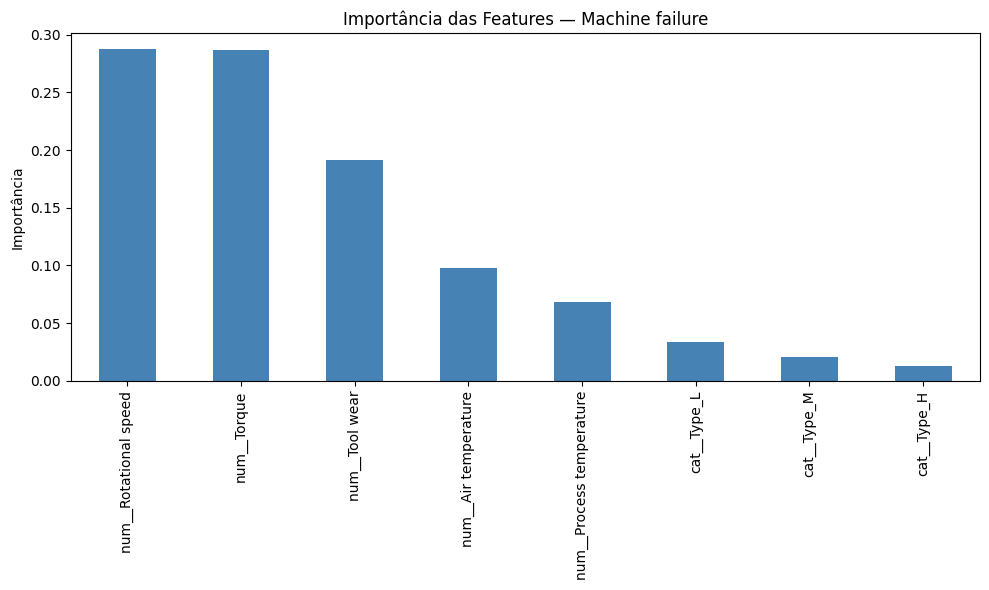

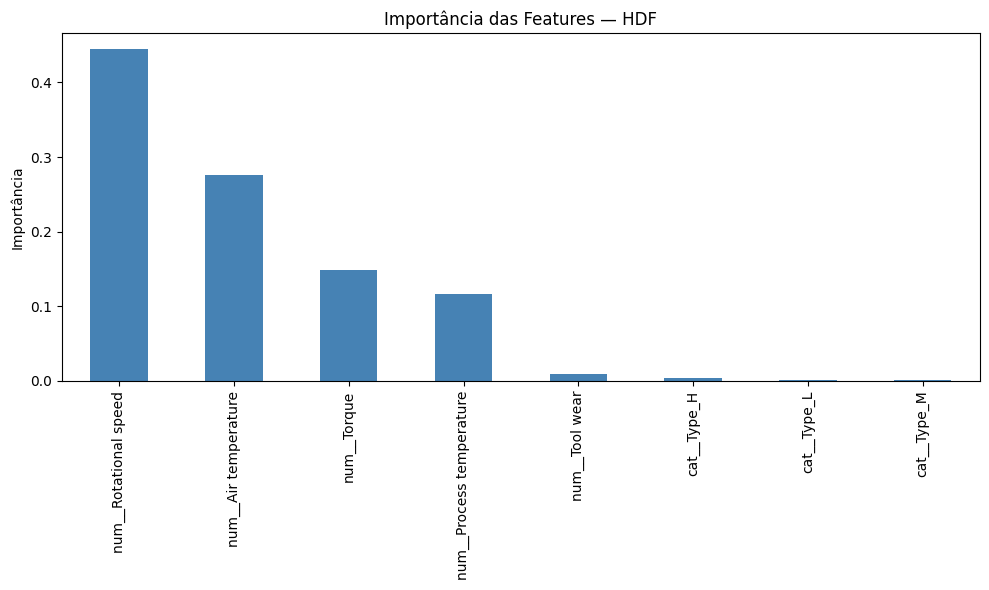

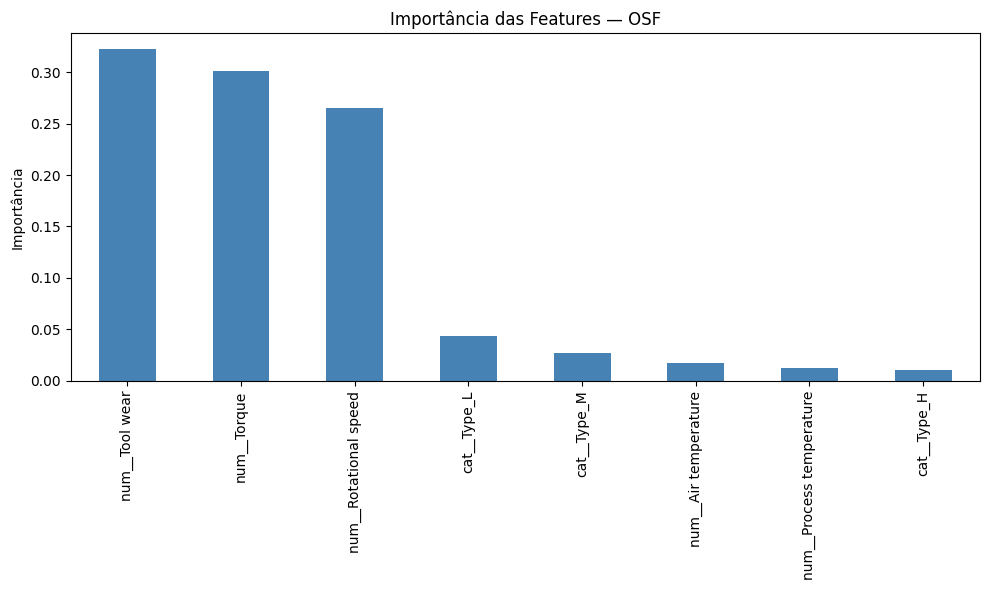

In [15]:
# Treino e avaliação
trainer_machine = ModelTrainer(prep_machine)
trainer_hdf     = ModelTrainer(prep_hdf)
trainer_osf     = ModelTrainer(prep_osf)

trainer_machine.evaluate()
trainer_hdf.evaluate()
trainer_osf.evaluate()

# Feature importance
trainer_machine.feature_importance()
trainer_hdf.feature_importance()
trainer_osf.feature_importance()

# **Respondendo nossas hipóteses**

Respostas das hipóteses do MVP.



## **Hipótese 1**
**O conjunto de dados apresenta desbalanceamento entre as classes, com maior quantidade de observações sem falha do que com falha.**

Os gráficos de distribuição de classes confirmam o desbalanceamento entre as classes para os três targets analisados:

- Machine failure: 9.661 operações normais vs 339 falhas (3,4%)
- HDF - falha por dissipação de calor: 9.885 operações normais vs 115 falhas (1,15%)
- OSF: 9.902 operações normais vs 98 falhas (0,98%)

O desbalanceamento é progressivamente mais severo nos modos de falha específicos. Para contornar esse problema, foi aplicado SMOTE no conjunto de treino, igualando o número de casos de falha e operação normal antes do treinamento dos modelos.

## **Hipótese 2**
**Variáveis operacionais como torque, velocidade de rotação, temperatura do processo e desgaste da ferramenta influenciam a ocorrência de falhas.**

Os gráficos de boxplot gerados na seção de análise de dados confirmam que as variáveis operacionais têm influência na ocorrência de falhas. As relações são mais intensas e específicas para os modos de falha especializados como HDF e OSF usados neste MVP.

- Para machine failure, torque, velocidade de rotação (rotational speed) e desgaste da ferramenta (tool wear) são as mais relevantes. As temperaturas apresentam pouca separação entre as classes.
- Para HDF, temperatura do ar e velocidade de rotação foram as que melhor diferenciaram falha e operação normal. A diferença entre temperaturas foi o principal indicador de falha.
- Para OSF, torque, velocidade de rotação e desgaste de ferramenta são mais relevantes. As temperaturas não apresentam relação com este modo de falha.

No teste, a análise de importância das features do Random Forest indica  que velocidade de rotação e torque são as variáveis mais relevantes  para a detecção de falhas em Machine failure (28%), seguidas  pelo desgaste da ferramenta (19%).
Para HDF, a velocidade de rotação foi mais importante (42%) seguido por temperatura do ar (28%).
Para OSF, o desgaste de ferramenta foi mais importante (32%) seguido pelo torque (29%). Velocidade de rotação também foi relevante (25%).


## **Hipótese 3**
**Certas combinações de variáveis operacionais podem estar mais associadas à falha do equipamento do que outras.**



As combinações podem ser validadas pelos gráficos scatter pairs.
As combinações são:
- Torque vs velocidade de rotação: relação hiperbólica decrescente. Quando o torque é baixo, a rotação é alta. Quando o toque é alto, a rotação é baixa. As falhas se concentram nas extremidades. Isso confirma que há uma relação entre torque e velocidade de rotação relacionado à falha.
- Torque vs desgaste de ferramenta: não há como confirmar a relação entre as duas variáveis e a relação com falha na região central onde há um sobreposicionamento. Há mais falhas nas extremidades.
- Temperatura do ar vs temperatura do processo: correlação linear crescente é alta. A temperatura de processo é  aproximadamente 10K maior que a do ar em todos os pontos.  Os casos de falha estão misturados com os de operação normal,  sem separação visual, indicando pouca relação direta com falha.


##**Hipótese 4**
**É possível prever se um equipamento falhará a partir das variáveis operacionais disponíveis no dataset.**

É possível prever falhas a partir das variáveis operacionais. Os resultados foram melhores para os targets com modo específico de falha.

- **Machine failure:**
  - Matriz de confusão: VN: 2823 | FP: 75 | FN: 31 | VP: 71
  - Precision (falha): 0,49
  - Recall (falha): 0,70
  -  F1-Score (falha): 0,57
- **HDF:**
  - Matriz de confusão: VN: 2960 | FP: 6 | FN: 8 | VP: 26
  - Precision (falha): 0,81
  - Recall (falha): 0,76
  - F1-Score (falha): 0,79
- **OSF:**
  - Matriz de confusão: VN: 2966 | FP: 5 | FN: 10 | VP: 19
  - Precision (falha): 0,79
  - Recall (falha): 0,66
  - F1-Score (falha): 0,72

VN: Verdadeiro negativo (operação normal)
FP: Falso positivo (alarme falso)
FN: Falso negativo (falha não detectada)
VP: Verdadeiro positivo (detecção de falha)

Os resultados mostram que, embora seja possível prever falhas a partir das variáveis operacionais, o modelo apresenta limitações relevantes para a variável “Machine failure”, com recall de 0,70, o que significa que cerca de 30% das falhas reais não são detectadas.

Para os modos específicos de falha, o desempenho variou: enquanto o modelo apresentou melhor recall para HDF (0,76), o desempenho para OSF foi inferior (0,66). Isso indica que a capacidade preditiva depende do tipo de falha analisado. Em manutenção preditiva, o recall é uma métrica importante, pois falhas não detectadas podem gerar impactos operacionais relevantes.



##**Hipótese 5**
**Modelos especializados por modo de falha (HDF e OSF)  apresentam melhor desempenho preditivo do que um modelo generalista treinado sobre o target Machine failure, que reúne os resultados das falhas específicas.**

Os resultados do F1-Score para a classe de falha demonstram a superioridade dos modelos especializados (que usam modo de falhas específicos):

- Machine failure: 0,57
- HDF: 0,79
- OSF: 0,72

O modelo generalista (Machine failure) tenta aprender simultaneamente cinco padrões de falha distintos com variáveis relevantes diferentes para cada modo. Isso dilui o sinal preditivo e resulta no menor F1-Score. Os modelos especializados, ao focarem em um único modo de falha com suas variáveis específicas, conseguem aprender fronteiras de decisão mais precisas.

#**Conclusão**

Os resultados indicam que é possível prever falhas em equipamentos industriais a partir das variáveis operacionais, mas o desempenho varia significativamente conforme o target e a abordagem de modelagem.

A análise exploratória antecipou parte dos resultados. O scatter plot de torque versus velocidade de rotação revelou concentração de falhas nas extremidades da curva, e ambas as variáveis estão presentes entre as mais importantes nos três modelos individualmente, ainda que a relação entre elas não possa ser estabelecida pela *feature importance*. Para OSF, a separação de desgaste da ferramenta já era visível na análise exploratória de dados, com falhas concentradas acima de 190 minutos, o que se refletiu na maior importância dessa feature no modelo (32%). Para Machine failure, os boxplots mostravam separação menos nítida entre as classes em todas as variáveis, antecipando a dificuldade do modelo generalista.

O modelo HDF obteve o melhor desempenho (F1 = 0,79), resultado coerente com a existência de variáveis com forte separação entre falha e operação normal, como temperatura do ar e velocidade de rotação. O limite de 8,6K descrito por Matzka, S (2020) confirmou o mecanismo físico da falha, visível na análise exploratória, ainda que o Random Forest capture esse sinal através das temperaturas individuais, conforme verificado em versões iniciais do MVP sem a feature de delta.

O modelo generalista com Machine failure (F1 = 0,57) apresentou o pior desempenho, esperado dado que este target reúne cinco modos de falha com variáveis relevantes distintas, diluindo o sinal preditivo.

Como conclusão, a modelagem por modo específico de falha é mais eficaz do que a modelagem geral, sugerindo que, em aplicações reais, múltiplos modelos especializados tendem a produzir resultados mais confiáveis do que um modelo único reunindo modos de falhas específicos.

#**Referências**


AI4I 2020 Predictive Maintenance Dataset [Dataset]. (2020).  UCI Machine Learning Repository. DOI: https://doi.org/10.24432/C5HS5C. Disponível em: https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset. Acesso em: abr. 2026.


MATZKA, S. Explainable Artificial Intelligence for Predictive Maintenance
Applications. In: International Conference on Artificial Intelligence for
Industries (AI4I), 3., 2020. Proceedings [...]. IEEE, 2020.
DOI: 10.1109/AI4I49448.2020.00023

Python Software Foundation. Python Language Reference.
Disponível em: https://www.python.org. Acesso em: abr. 2026.

VAN ROSSUM, G.; WARSAW, B. PEP 8 — Style Guide for Python Code.
Python Software Foundation, 2001.
Disponível em: https://peps.python.org/pep-0008/. Acesso em: abr. 2026.

KALINOWSKI, M.; ESCOVEDO, T.; VILLAMIZAR, H.; LOPES, H.
Engenharia de Software para Ciência de Dados: um guia de boas práticas
com ênfase na construção de sistemas de Machine Learning em Python.
Casa do Código, maio 2023. 476 p. ISBN 978-85-5519-334-7.